# Experiment Analysis

This notebook analyzes the experiment results from `20251130` and `20251201`.

In [61]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import importlib
import log_parser

# Force reload to pick up latest changes
importlib.reload(log_parser)

# Set plot style
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [62]:
# Define directories
# We check where we are running from to construct paths correctly
cwd = os.getcwd()
print(f"Current working directory: {cwd}")

dirs = ['20251130/base', '20251201/base', '20251202/base', '20251203', '20251204']
# dirs = ['20251203']

if 'workspace/exp/harness' in cwd:
    # Running inside harness dir
    target_dirs = [d for d in dirs]
else:
    # Assuming running from project root
    target_dirs = [os.path.join('workspace/exp/harness', d) for d in dirs]

# Get successful logs
logs = log_parser.get_successful_logs(target_dirs)
print(f"Found {len(logs)} successful logs")

Current working directory: /iopsstor/scratch/cscs/xjin/repos/sglang/workspace/exp/harness
Found 211 successful logs


In [63]:
# Parse logs and extract info
data = []
for log in logs:
    try:
        info = log_parser.get_experiment_info(log)
        score = info.extract_score()
        if score is not None:
            entry = info.params.copy()
            entry['score'] = score
            # Ensure specific columns are present and consistent
            entry['task'] = info.task
            entry['model'] = info.model
            entry['method'] = info.method
            
            # Convert numeric fields
            for k in ['bsz', 'pg', 'graph', 'run', 'topk', 'wind', 'sink']:
                if k in entry:
                    try:
                        if entry[k] != 'auto' and entry[k] != 'none':
                            entry[k] = int(entry[k])
                    except ValueError:
                        pass
            for k in ['frac', 'limit']:
                 if k in entry:
                    try:
                        if entry[k] != 'none':
                            entry[k] = float(entry[k])
                    except ValueError:
                        pass
            data.append(entry)
    except Exception as e:
        print(f"Error processing {log}: {e}")

df = pd.DataFrame(data)
print(f"Parsed {len(df)} records")
if not df.empty:
    display(df.head())
else:
    print("DataFrame is empty. Check logs path or log content.")

Parsed 211 records


,method,model,pg,graph,frac,limit,bsz,ctx,tasks,topk,est,run,score,task,wind,sink
0,quest,qw_30b_th,8,1,0.74,none,8,none,mmlu,32.0,triton,1,0.7854,mmlu,NaN,NaN
1,stream,qw_30b,1,1,0.74,none,8,none,mmlu,NaN,NaN,1,0.8017,mmlu,2048.0,4.0
2,stream,qw_30b_th,1,1,0.76,none,8,none,aime24,NaN,NaN,1,0.0000,aime24,128.0,4.0
3,quest,qw_4b,16,1,0.70,none,8,none,aime24,32.0,triton,1,0.2000,aime24,NaN,NaN
4,quest,qw_30b_th,16,1,0.74,none,8,none,ruler,16.0,triton,1,0.0599,ruler,NaN,NaN


In [64]:
# Pivot table to see results by Task and Method/Model
if not df.empty and 'score' in df.columns:
    pivot = df.pivot_table(index=['task', 'model'], columns=['method'], values='score', aggfunc='mean')
    display(pivot)
else:
    print("Cannot create pivot table: DataFrame is empty or missing 'score' column.")

method                   base     quest    stream
task      model                                  
aime24    qw_30b     0.066700  0.023800  0.020000
          qw_30b_th  0.133300  0.014271  0.006660
          qw_4b      0.400000  0.166662  0.053340
longbench qw_30b     0.345500  0.142485  0.216448
          qw_30b_th  0.249517  0.104642  0.152927
          qw_4b      0.309700  0.130985  0.171488
mmlu      qw_30b     0.800300  0.801700  0.801680
          qw_30b_th  0.786600  0.785412  0.785420
          qw_4b      0.705600  0.705550  0.705550
ruler     qw_30b     0.956400  0.213475  0.355190
          qw_30b_th  0.852300  0.174038  0.270560
          qw_4b      0.939200  0.320825  0.347690

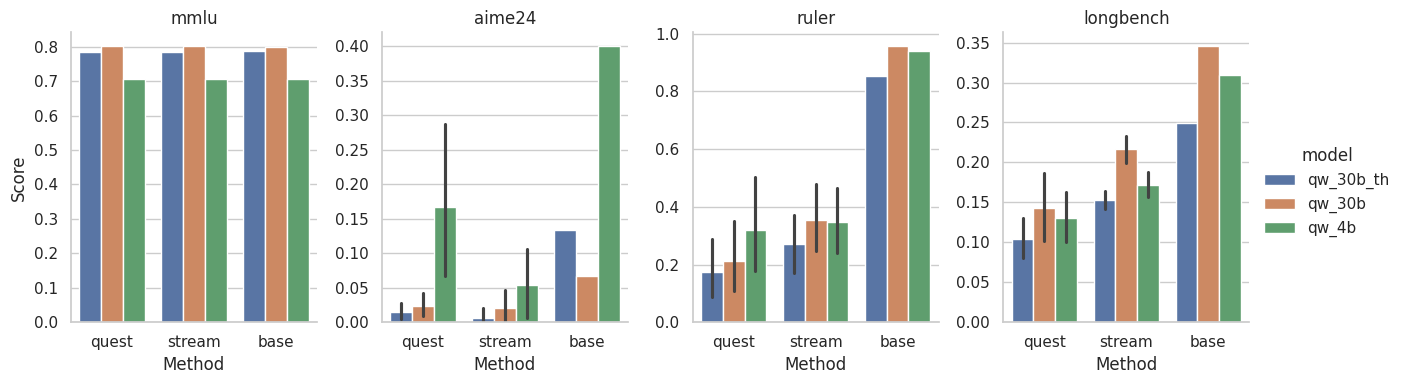

In [65]:
# Simple Visualization: Score by Method for each Task
if not df.empty and 'score' in df.columns:
    g = sns.catplot(
        data=df,
        x="method", 
        y="score", 
        col="task", 
        hue="model",
        kind="bar",
        height=4, 
        aspect=0.8,
        sharey=False
    )
    g.set_axis_labels("Method", "Score")
    g.set_titles("{col_name}")
    plt.show()
else:
    print("Cannot plot: DataFrame is empty or missing 'score' column.")

### Quest Analysis: Top-K vs Score

Analysis of how the Top-K parameter affects the score in the `quest` method, comparing different Page Sizes (`pg`) and Models.

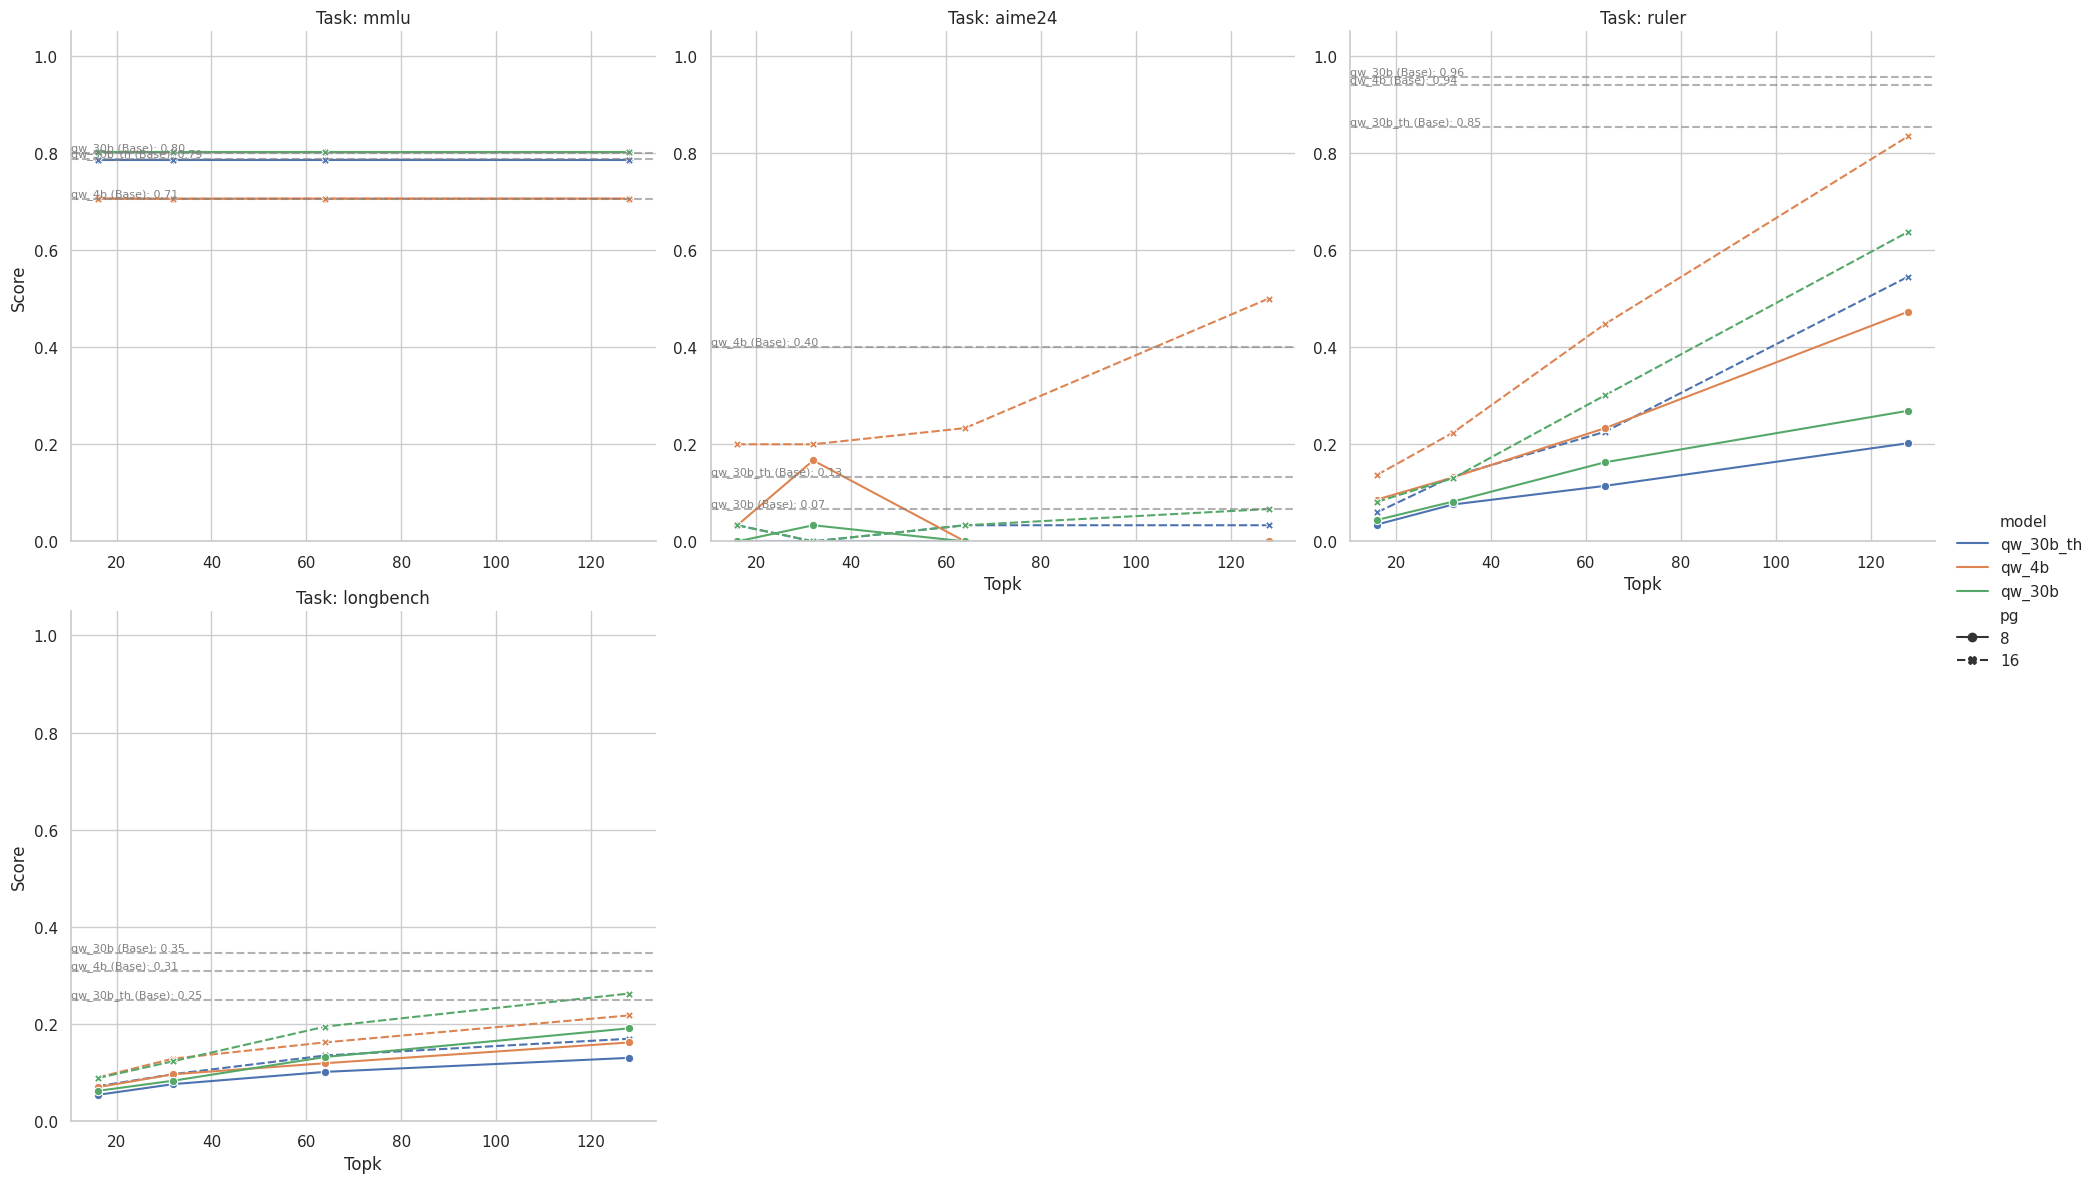

In [66]:
def plot_with_baseline(data_df, x_axis, style_col, title_prefix):
    if not data_df.empty:
        # Ensure style column is string for proper legend
        if style_col in data_df.columns:
            data_df[style_col] = data_df[style_col].astype(str)
        
        g = sns.relplot(
            data=data_df,
            x=x_axis,
            y="score",
            hue="model",
            style=style_col,
            col="task",
            col_wrap=3, # 1 row, 3 columns (if 3 tasks)
            kind="line",
            markers=True,
            height=6,
            aspect=1.1, # roughly square subplots, making total width ~18-20
            facet_kws={'sharey': False, 'sharex': False}
        )
        
        # Add baseline lines
        axes = g.axes.flatten()
        
        # Calculate baseline scores if baseline exists in overall df
        baseline_df = df[df['method'] == 'base'].copy()
        if not baseline_df.empty:
            baseline_scores = baseline_df.groupby(['task', 'model'])['score'].mean().to_dict()
            
            # Map axes to tasks
            # relplot sorts tasks alphabetically usually
            # We can get the task from the title or g.col_names
            
            for ax, task in zip(axes, g.col_names):
                # Identify models in this specific plot
                models = data_df[data_df['task'] == task]['model'].unique()
                
                for model in models:
                    base_score = baseline_scores.get((task, model))
                    if base_score is not None:
                        ax.axhline(y=base_score, linestyle='--', color='gray', alpha=0.6)
                        # Annotation
                        ax.text(x=ax.get_xlim()[0], y=base_score, s=f'{model} (Base): {base_score:.2f}', 
                                va='bottom', ha='left', fontsize=8, color='gray')

        g.set_axis_labels(x_axis.capitalize(), "Score")
        g.set_titles("Task: {col_name}")
        
        for ax in axes:
            ax.set_ylim(0, 1.05)
            
        plt.show()
    else:
        print(f"No data found for {title_prefix}")

if not df.empty and 'score' in df.columns:
    quest_df = df[df['method'] == 'quest'].copy()
    plot_with_baseline(quest_df, "topk", "pg", "Quest")
else:
    print("Cannot plot: DataFrame is empty or missing 'score' column.")

In [67]:
# show all data
print(df[(df['method']=='quest')&(df['task']=='longbench')&(df['pg']==8)&(df['model']!='qw_4b')].sort_values(by='model', ascending=False))
# print(df)

    method      model  pg  graph  frac limit  bsz   ctx      tasks   topk     est  run     score       task  wind  sink
40   quest  qw_30b_th   8      1  0.76  none    8  none  longbench   32.0  triton    1  0.076450  longbench   NaN   NaN
44   quest  qw_30b_th   8      1  0.76  none    8  none  longbench   16.0  triton    1  0.054283  longbench   NaN   NaN
61   quest  qw_30b_th   8      1  0.76  none    8  none  longbench  128.0  triton    1  0.130483  longbench   NaN   NaN
77   quest  qw_30b_th   8      1  0.76  none    8  none  longbench   64.0  triton    1  0.101667  longbench   NaN   NaN
28   quest     qw_30b   8      1  0.76  none    8  none  longbench   16.0  triton    1  0.062500  longbench   NaN   NaN
58   quest     qw_30b   8      1  0.76  none    8  none  longbench  128.0  triton    1  0.191267  longbench   NaN   NaN
124  quest     qw_30b   8      1  0.76  none    8  none  longbench   32.0  triton    1  0.083550  longbench   NaN   NaN
166  quest     qw_30b   8      1  0.76  

### Stream Analysis: Window Size vs Score

Analysis of how the Window Size (`wind`) parameter affects the score in the `stream` method.

Filtering Stream results for pg=1 as requested.


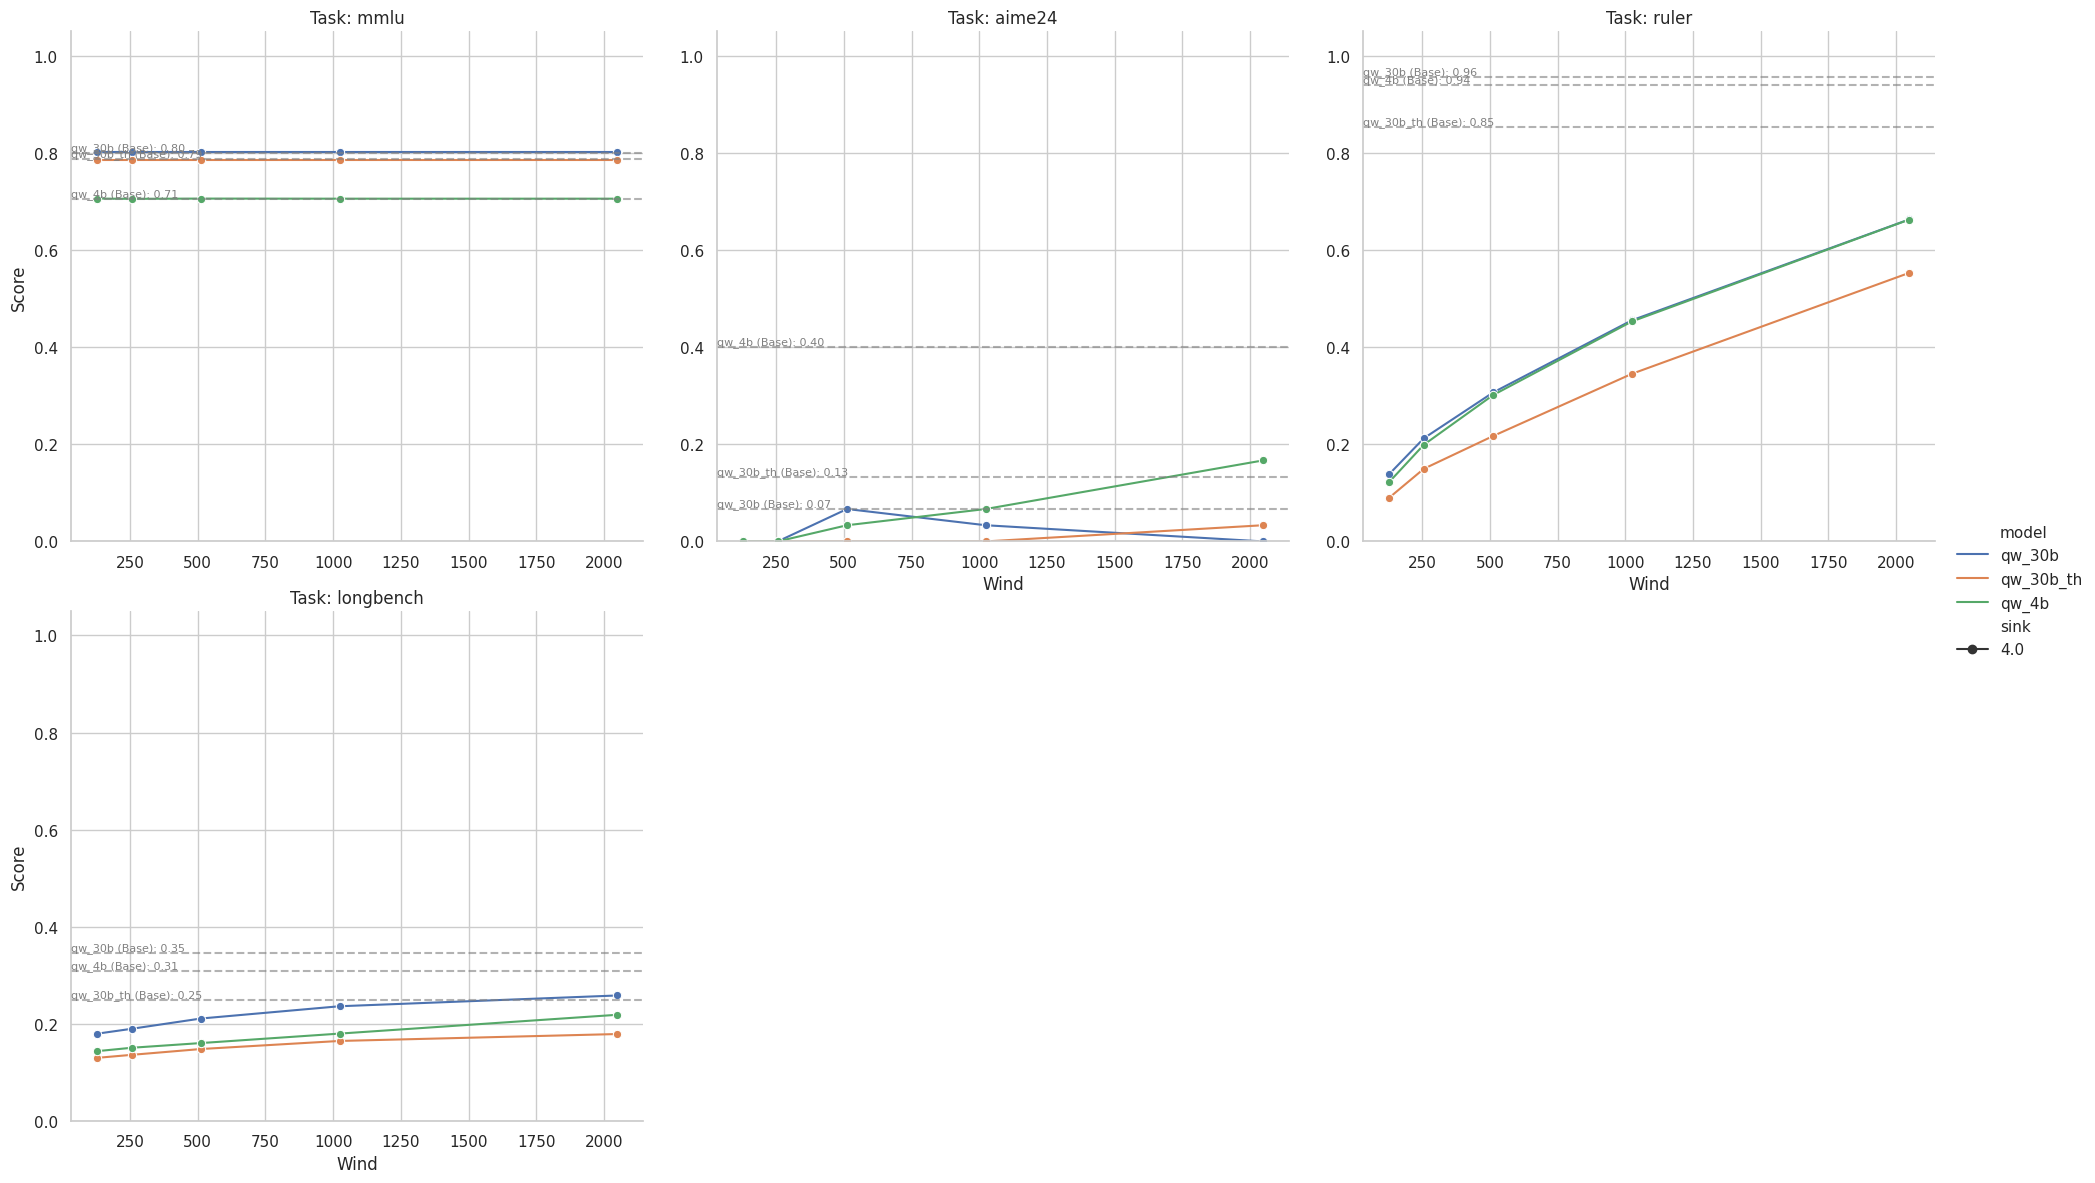

In [68]:
if not df.empty and 'score' in df.columns:
    # Filter for 'stream' method
    stream_df = df[df['method'] == 'stream'].copy()
    
    # Filter for pg=1 if available, as requested
    # First check if 1 exists in the 'pg' column for stream
    if 'pg' in stream_df.columns:
        # Check values
        available_pgs = stream_df['pg'].unique()
        if 1 in available_pgs:
            print("Filtering Stream results for pg=1 as requested.")
            stream_df = stream_df[stream_df['pg'] == 1]
        else:
            print(f"Note: pg=1 not found in Stream results (available: {available_pgs}). Using all available data.")
    
    plot_with_baseline(stream_df, "wind", "sink", "Stream")
else:
    print("Cannot plot: DataFrame is empty or missing 'score' column.")